In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [4]:
import re
import pandas as pd

resnet_report_path = '../results/ph05_transfer_outputs/resnet18_derm7pt_classification_report.txt'
try:
    with open(resnet_report_path, 'r') as f:
        report_text = f.read()
    acc_match = re.search(r'accuracy\s+([0-9.]+)', report_text)
    if acc_match:
        resnet_final_acc = float(acc_match.group(1))
    else:
        resnet_final_acc = 0.5747
except FileNotFoundError:
    print("Không tìm thấy file report của ResNet18. Sử dụng giá trị mặc định.")
    resnet_final_acc = 0.5747

vit_metrics_path = '../results/ph06_evaluation_outputs/ph06_evaluation_outputs/vit_metrics_summary.csv'
try:
    vit_metrics_df = pd.read_csv(vit_metrics_path)
    vit_acc = vit_metrics_df['Accuracy'].iloc[0]
except FileNotFoundError:
    print("Không tìm thấy file log của ViT. Sử dụng giá trị mặc định.")
    vit_acc = 0.7823

print("-" * 40)
print(f"ResNet18 Validation Accuracy : {resnet_final_acc*100:.2f}%")
print(f"ViT Evaluation Accuracy      : {vit_acc*100:.2f}%")

----------------------------------------
ResNet18 Validation Accuracy : 66.33%
ViT Evaluation Accuracy      : 78.23%


Đã xuất ảnh và lưu tại: ../results/ph07_model_comparison\accuracy_comparison.png


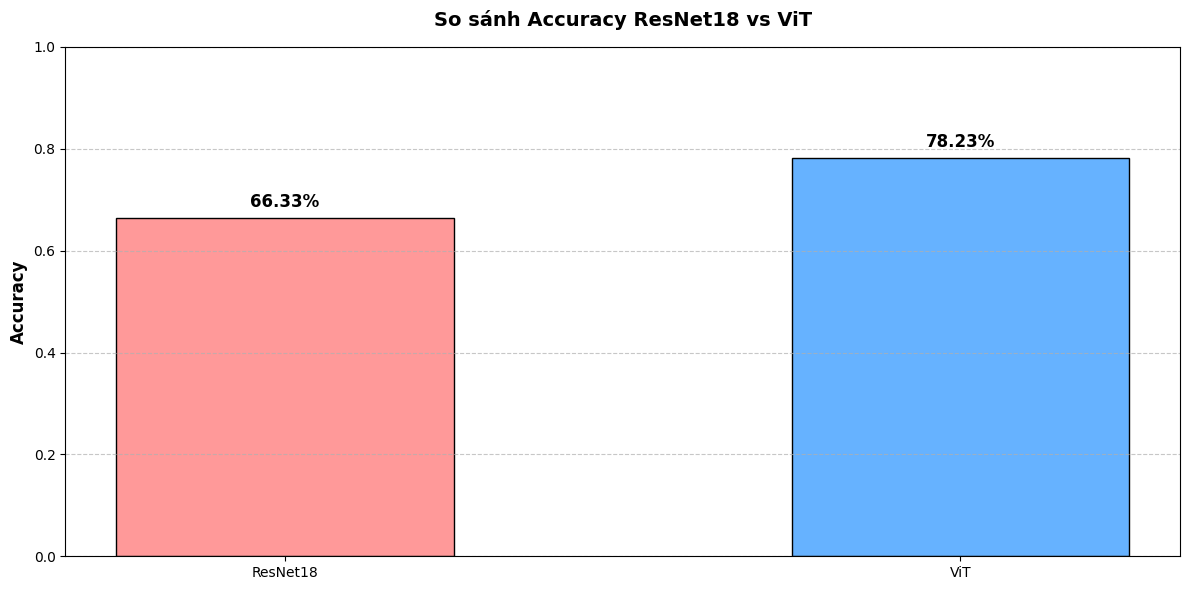

In [5]:
output_dir = '../results/ph07_model_comparison'
os.makedirs(output_dir, exist_ok=True)

models = ['ResNet18', 'ViT']
accuracies = [resnet_final_acc, vit_acc] 

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(models, accuracies, color=['#FF9999', '#66B2FF'], edgecolor='black', width=0.5)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('So sánh Accuracy ResNet18 vs ViT', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height*100:.2f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

save_path_acc = os.path.join(output_dir, 'accuracy_comparison.png')
plt.savefig(save_path_acc, dpi=300, bbox_inches='tight')
print(f"Đã xuất ảnh và lưu tại: {save_path_acc}")

plt.show()

In [6]:
output_dir = '../results/ph07_model_comparison'
os.makedirs(output_dir, exist_ok=True)

classes = ['bcc', 'mel', 'misc', 'nevus', 'sk']
x = np.arange(len(classes))
width = 0.35  

resnet_p  = [0.26, 0.46, 0.47, 0.84, 0.27]
resnet_r  = [0.75, 0.57, 0.68, 0.58, 0.21]
resnet_f1 = [0.39, 0.51, 0.56, 0.68, 0.24]

resnet_report_path = '../results/ph05_transfer_outputs/resnet18_derm7pt_classification_report.txt'
if os.path.exists(resnet_report_path):
    with open(resnet_report_path, 'r') as f:
        report_text = f.read()
    import re
    p_list, r_list, f1_list = [], [], []
    for cls in classes:
        match = re.search(fr'{cls}\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)', report_text)
        if match:
            p_list.append(float(match.group(1)))
            r_list.append(float(match.group(2)))
            f1_list.append(float(match.group(3)))
    if len(p_list) == len(classes):
        resnet_p, resnet_r, resnet_f1 = p_list, r_list, f1_list

vit_p  = [0.82, 0.73, 0.63, 0.85, 0.57]
vit_r  = [0.56, 0.73, 0.60, 0.87, 0.63]
vit_f1 = [0.67, 0.73, 0.62, 0.86, 0.60]

metrics = [
    (resnet_p, vit_p, 'Precision', 'precision_comparison.png'),
    (resnet_r, vit_r, 'Recall', 'recall_comparison.png'),
    (resnet_f1, vit_f1, 'F1-Score', 'f1_score_comparison.png')
]

data = {
    'Class': classes,
    'Precision (ResNet18)': resnet_p,
    'Precision (ViT)': vit_p,
    'Recall (ResNet18)': resnet_r,
    'Recall (ViT)': vit_r,
    'F1-Score (ResNet18)': resnet_f1,
    'F1-Score (ViT)': vit_f1
}

df_comparison = pd.DataFrame(data)
df_comparison.set_index('Class', inplace=True)

csv_filename = 'metrics_comparison_summary.csv'
save_path_csv = os.path.join(output_dir, csv_filename)

df_comparison.to_csv(save_path_csv, index=True, float_format='%.2f')

display(df_comparison)

,Precision (ResNet18),Precision (ViT),Recall (ResNet18),Recall (ViT),F1-Score (ResNet18),F1-Score (ViT)
Class,,,,,,
bcc,0.3095,0.82,0.8125,0.56,0.4483,0.67
mel,0.5644,0.73,0.5644,0.73,0.5644,0.73
misc,0.6190,0.63,0.6500,0.60,0.6341,0.62
nevus,0.8394,0.85,0.7397,0.87,0.7864,0.86
sk,0.2353,0.57,0.2105,0.63,0.2222,0.60


Đã xuất ảnh Precision và lưu tại: ../results/ph07_model_comparison\precision_comparison.png


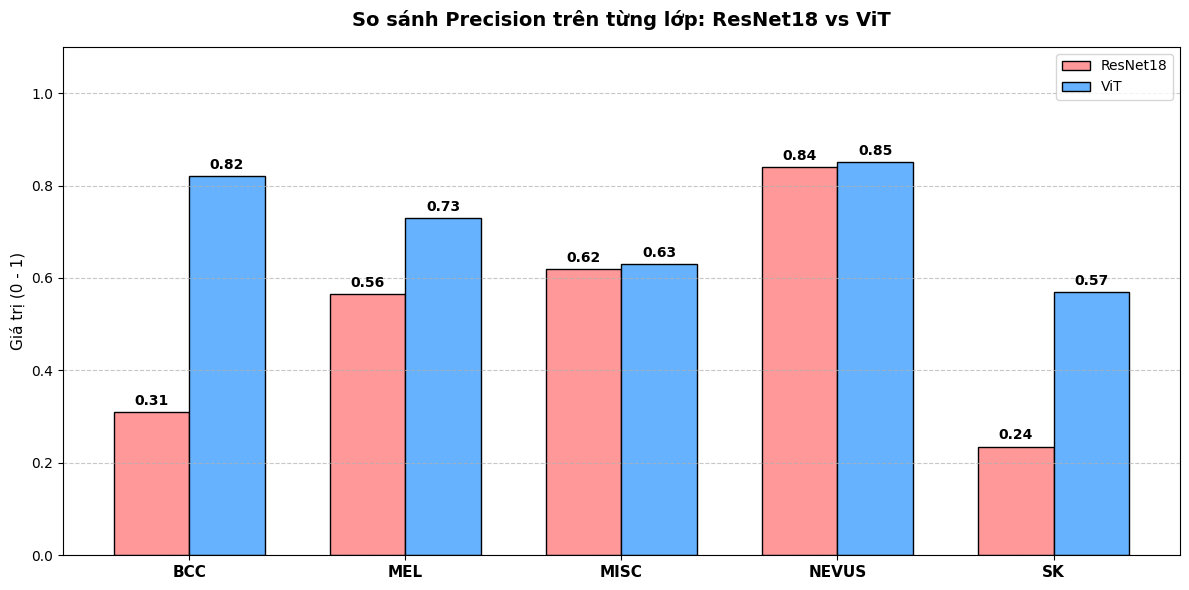

Đã xuất ảnh Recall và lưu tại: ../results/ph07_model_comparison\recall_comparison.png


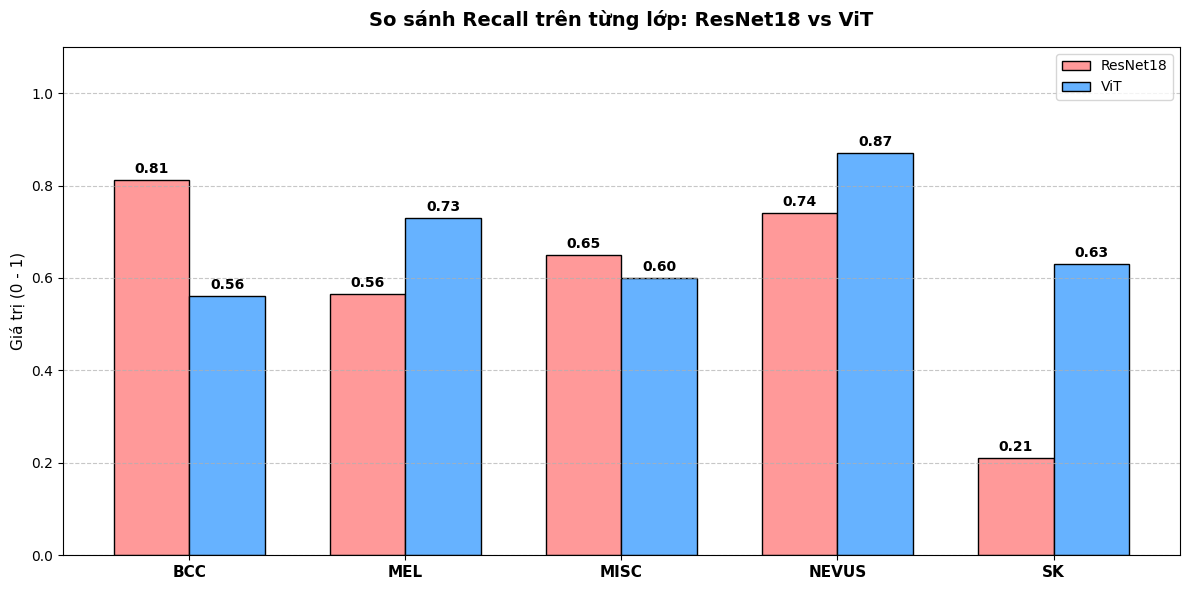

Đã xuất ảnh F1-Score và lưu tại: ../results/ph07_model_comparison\f1_score_comparison.png


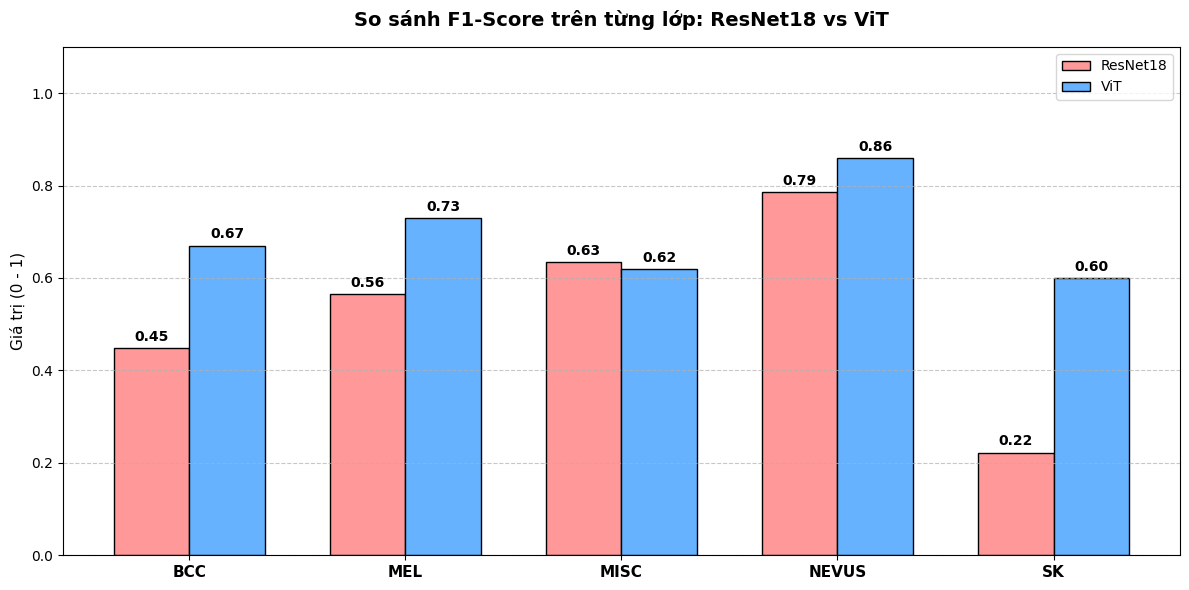

In [7]:
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

for res_data, vit_data, title, filename in metrics:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    rects1 = ax.bar(x - width/2, res_data, width, label='ResNet18', color='#FF9999', edgecolor='black')
    rects2 = ax.bar(x + width/2, vit_data, width, label='ViT', color='#66B2FF', edgecolor='black')
    
    ax.set_ylabel('Giá trị (0 - 1)', fontsize=11)
    ax.set_title(f'So sánh {title} trên từng lớp: ResNet18 vs ViT', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([c.upper() for c in classes], fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    autolabel(rects1, ax)
    autolabel(rects2, ax)
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Đã xuất ảnh {title} và lưu tại: {save_path}")
    
    plt.show()

## Tổng kết: Ưu và Nhược điểm của ResNet18 và ViT

### Mô hình ResNet18 (Convolutional Neural Network)

**Ưu điểm:**
* **Kiến trúc nhẹ, tối ưu tài nguyên:** ResNet18 có cấu trúc ít tham số, tiêu tốn ít bộ nhớ GPU và có tốc độ huấn luyện cũng như suy luận rất nhanh. Rất phù hợp để triển khai trên các thiết bị có tài nguyên hạn chế.
* **Trích xuất đặc trưng cục bộ mạnh mẽ:** Cơ chế Convolution giúp mạng lưới cực kỳ nhạy bén với các chi tiết vi mô như kết cấu da, đường viền, điểm màu và hình dạng cục bộ của vết thương.
* **Khả năng phát hiện tốt ở một số lớp bệnh:** Đối với lớp Ung thư biểu mô tế bào đáy (`bcc`), mô hình đạt Recall khoảng 0.81, cho thấy khả năng phát hiện được phần lớn các trường hợp thuộc lớp này.
* **Hoạt động ổn định trên tập dữ liệu vừa và nhỏ:** Nhờ các giả định quy nạp (Inductive Bias) vốn có của CNN, ResNet18 có thể hội tụ tương đối hiệu quả ngay cả khi lượng dữ liệu huấn luyện không quá lớn.

**Nhược điểm:**
* **Thiếu khả năng khai thác ngữ cảnh toàn cục:** Do chủ yếu tập trung vào các vùng cục bộ của ảnh, mô hình gặp khó khăn trong việc học mối quan hệ giữa các vùng tổn thương ở khoảng cách xa nhau.
* **Hiệu suất chưa đồng đều giữa các lớp:** Kết quả phân loại thay đổi đáng kể giữa các nhóm bệnh khác nhau, đặc biệt là các lớp có ít dữ liệu huấn luyện.
* **Nhạy cảm với dữ liệu mất cân bằng:** Lớp Dày sừng tiết bã (`sk`) chỉ đạt Precision 0.24, Recall 0.21 và F1-score 0.22, cho thấy mô hình gặp nhiều khó khăn trong việc nhận diện lớp thiểu số này.
* **Độ tin cậy còn hạn chế đối với lớp ác tính:** Đối với lớp Ung thư hắc tố (`mel`), Precision, Recall và F1-score đều chỉ đạt khoảng 0.56, thấp hơn đáng kể so với ViT, phản ánh khả năng phân biệt các tổn thương ác tính vẫn còn hạn chế.

---

### Mô hình Vision Transformer (ViT)

**Ưu điểm:**
* **Cơ chế Self-Attention toàn cục:** Thay vì quét từng vùng nhỏ, ViT chia ảnh thành các patches và tính toán mức độ chú ý giữa tất cả các mảnh ngay từ những lớp đầu tiên. Khả năng nhìn nhận bối cảnh tổng thể (mối quan hệ giữa vùng tổn thương và da lành xung quanh) giúp ViT vượt trội trong phân tích ảnh y tế.
* **Hiệu suất vượt trội trên hầu hết các lớp bệnh:** ViT đạt F1-score cao hơn ResNet18 ở tất cả các lớp, bao gồm:
`bcc`: 0.67 so với 0.45
`mel`: 0.73 so với 0.56
`misc`: 0.62 so với 0.63 (xấp xỉ tương đương)
`nevus`: 0.86 so với 0.79
`sk`: 0.60 so với 0.22
* **Xử lý tốt hơn các lớp thiểu số:** Đặc biệt ở lớp sk, F1-score tăng từ 0.22 lên 0.60, cho thấy khả năng học đặc trưng của các lớp ít dữ liệu tốt hơn đáng kể.
* **Độ tin cậy cao đối với lớp ung thư ác tính:** Với lớp mel, cả Precision và Recall đều đạt 0.73, giúp giảm đồng thời số lượng dự đoán sai và số trường hợp bị bỏ sót.
* **Hiệu suất cân bằng hơn giữa các lớp:** Các chỉ số F1-score của ViT dao động từ 0.60 đến 0.86, trong khi ResNet18 có sự chênh lệch lớn hơn giữa các lớp.


**Nhược điểm:**
* **Chi phí tính toán và tài nguyên lớn:** Quá trình tính toán ma trận Self-Attention rất phức tạp do tăng theo bình phương số lượng patch, đòi hỏi cấu hình phần cứng mạnh, tốn nhiều VRAM và thời gian huấn luyện lâu hơn hẳn ResNet18.
* **Phụ thuộc mạnh vào Transfer Learning:** Do không có sẵn các giả định quy nạp tự nhiên như CNN, ViT cần một lượng dữ liệu khổng lồ để tự học các quy luật thị giác. Nếu không có bước Pre-train/Fine-tune trên tập lớn như ImageNet hay HAM10000, ViT gần như không thể hội tụ và hoạt động tốt nếu chỉ train từ đầu trên một tập dữ liệu nhỏ như Derm7pt.
* **Vẫn tồn tại sự đánh đổi giữa Precision và Recall ở một số lớp:** Ví dụ, với lớp bcc, ViT đạt Precision rất cao (0.82) nhưng Recall chỉ 0.56, cho thấy mô hình dự đoán chính xác hơn khi xác định bệnh nhưng vẫn có thể bỏ sót một số trường hợp thực tế.